# **Universidad de Buenos Aires**
# Maestría en Inteligencia Artificial (FIUBA) - Aprendizaje por Refuerzo I
# Tema: SARSA y Q-Learning en CliffWalking
---
# Trabajo Práctico 2

De acuerdo a la siguiente celda resolver y responder las preguntas modificando el código original y reescribiéndolo luego de cada pregunta.


(En esta celda se implementan los algoritmos **SARSA** y **Q-Learning** originales de Sutton & Barto, aplicados al entorno **CliffWalking** de `gymnasium`, y se comparan sus resultados. A lo largo del TP se irán realizando ajustes progresivos hasta lograr que ambos aprendan una política satisfactoria.)

Ep 50 | ε=0.300 | SARSA (últ. 50): -176.5 | Q-Learning (últ. 50): -284.3


Ep 100 | ε=0.300 | SARSA (últ. 50): -46.1 | Q-Learning (últ. 50): -149.5


Ep 150 | ε=0.300 | SARSA (últ. 50): -54.5 | Q-Learning (últ. 50): -228.6


Ep 200 | ε=0.300 | SARSA (últ. 50): -73.6 | Q-Learning (últ. 50): -150.4


Ep 250 | ε=0.300 | SARSA (últ. 50): -118.5 | Q-Learning (últ. 50): -184.1


Ep 300 | ε=0.300 | SARSA (últ. 50): -59.4 | Q-Learning (últ. 50): -195.0


Ep 350 | ε=0.300 | SARSA (últ. 50): -58.7 | Q-Learning (últ. 50): -218.0


Ep 400 | ε=0.300 | SARSA (últ. 50): -58.7 | Q-Learning (últ. 50): -152.9


Ep 450 | ε=0.300 | SARSA (últ. 50): -81.8 | Q-Learning (últ. 50): -157.2


Ep 500 | ε=0.300 | SARSA (últ. 50): -50.0 | Q-Learning (últ. 50): -168.0


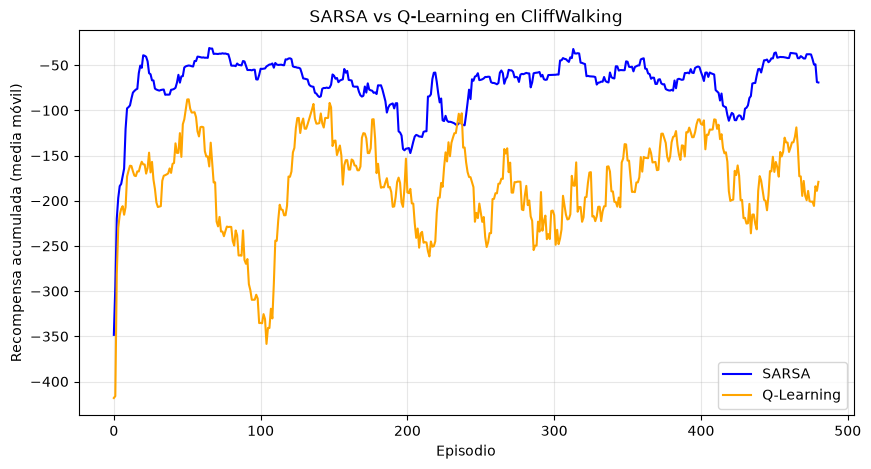


✅ Recompensa de la política final SARSA:      -200.0
✅ Recompensa de la política final Q-Learning: -13.0

Política aprendida — SARSA (↑ 0, → 1, ↓ 2, ← 3):
→ → ↑ ↑ → → ↓ → ↑ ↓ ← ← 
↑ → ↑ ↑ → ↑ → → → → ↑ ↓ 
↑ ↑ ↑ ↑ ↑ ↑ ↑ → ↑ ↑ → ↓ 
🤖 💧 💧 💧 💧 💧 💧 💧 💧 💧 💧 🎯 

Política aprendida — Q-Learning (↑ 0, → 1, ↓ 2, ← 3):
→ ↓ → → ↓ → ↓ → ↓ → ↓ ↓ 
↓ → → → → → → → → → → ↓ 
→ → → → → → → → → → → ↓ 
🤖 💧 💧 💧 💧 💧 💧 💧 💧 💧 💧 🎯 


In [1]:
# ============================================================
# Celda 1: Instalación e imports
# ============================================================
!pip install gymnasium matplotlib numpy -q

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# ============================================================
# Celda 2: Entorno y parámetros
# ============================================================
env = gym.make('CliffWalking-v1')

N_STATES = env.observation_space.n     # 48 estados (grilla 4x12)
N_ACTIONS = env.action_space.n         # 4 acciones: 0 arriba, 1 derecha, 2 abajo, 3 izquierda

NUM_EPISODES = 500
ALPHA = 0.5
GAMMA = 1.0
EPSILON = 0.3   # epsilon CONSTANTE (sin decaimiento) durante todo el entrenamiento

# ============================================================
# Celda 3: Inicialización de las tablas Q
# ============================================================
Q_sarsa = np.zeros((N_STATES, N_ACTIONS))
Q_qlearning = np.zeros((N_STATES, N_ACTIONS))

# ============================================================
# Celda 4: Política de comportamiento epsilon-greedy (común a ambos)
# ============================================================
def epsilon_greedy(Q, state, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(N_ACTIONS)
    return int(np.argmax(Q[state]))

def greedy(Q, state):
    return int(np.argmax(Q[state]))

# ============================================================
# Celda 5: Algoritmo SARSA (on-policy, Sutton & Barto)
# ============================================================
def run_sarsa_episode(Q, alpha, gamma, epsilon):
    state, _ = env.reset()
    action = epsilon_greedy(Q, state, epsilon)
    total_reward = 0
    done = False
    while not done:
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        next_action = epsilon_greedy(Q, next_state, epsilon)

        # Actualización SARSA: usa la acción REALMENTE tomada en s' (on-policy)
        Q[state][action] += alpha * (
            reward + gamma * Q[next_state][next_action] - Q[state][action]
        )

        state, action = next_state, next_action
        total_reward += reward
    return total_reward

# ============================================================
# Celda 6: Algoritmo Q-Learning (off-policy, Sutton & Barto)
# ============================================================
def run_qlearning_episode(Q, alpha, gamma, epsilon):
    state, _ = env.reset()
    total_reward = 0
    done = False
    while not done:
        action = epsilon_greedy(Q, state, epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Actualización Q-Learning: usa el máximo sobre s' (off-policy)
        best_next = np.max(Q[next_state])
        Q[state][action] += alpha * (
            reward + gamma * best_next - Q[state][action]
        )

        state = next_state
        total_reward += reward
    return total_reward

# ============================================================
# Celda 7: Entrenamiento de ambos agentes
# ============================================================
rewards_sarsa = []
rewards_qlearning = []
epsilon = EPSILON

for ep in range(NUM_EPISODES):
    r_sarsa = run_sarsa_episode(Q_sarsa, ALPHA, GAMMA, epsilon)
    r_qlearning = run_qlearning_episode(Q_qlearning, ALPHA, GAMMA, epsilon)

    rewards_sarsa.append(r_sarsa)
    rewards_qlearning.append(r_qlearning)

    if (ep + 1) % 50 == 0:
        avg_s = np.mean(rewards_sarsa[-50:])
        avg_q = np.mean(rewards_qlearning[-50:])
        print(f"Ep {ep+1} | ε={epsilon:.3f} | SARSA (últ. 50): {avg_s:.1f} | Q-Learning (últ. 50): {avg_q:.1f}")

# ============================================================
# Celda 8: Visualización comparativa
# ============================================================
def moving_average(x, w=20):
    return np.convolve(x, np.ones(w) / w, mode='valid')

plt.figure(figsize=(10, 5))
plt.plot(moving_average(rewards_sarsa), color='blue', label='SARSA')
plt.plot(moving_average(rewards_qlearning), color='orange', label='Q-Learning')
plt.xlabel('Episodio')
plt.ylabel('Recompensa acumulada (media móvil)')
plt.title('SARSA vs Q-Learning en CliffWalking')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# Celda 9: Evaluación y políticas finales
# ============================================================
def evaluate_policy(Q, n_eval=1, max_steps=200):
    """Ejecuta la política greedy (100% explotación) y devuelve la recompensa total."""
    total = 0
    for _ in range(n_eval):
        state, _ = env.reset()
        done = False
        steps = 0
        while not done and steps < max_steps:
            action = greedy(Q, state)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total += reward
            steps += 1
    return total / n_eval

print(f"\n✅ Recompensa de la política final SARSA:      {evaluate_policy(Q_sarsa):.1f}")
print(f"✅ Recompensa de la política final Q-Learning: {evaluate_policy(Q_qlearning):.1f}")

ARROWS = {0: '↑', 1: '→', 2: '↓', 3: '←'}
N_ROWS, N_COLS = 4, 12
CLIFF = set(range(37, 47))  # fila inferior, entre el inicio (36) y la meta (47)
START, GOAL = 36, 47

def print_policy(Q, name):
    print(f"\nPolítica aprendida — {name} (↑ 0, → 1, ↓ 2, ← 3):")
    for row in range(N_ROWS):
        line = ""
        for col in range(N_COLS):
            s = row * N_COLS + col
            if s == START:
                line += "🤖 "
            elif s == GOAL:
                line += "🎯 "
            elif s in CLIFF:
                line += "💧 "
            else:
                line += ARROWS[greedy(Q, s)] + " "
        print(line)

print_policy(Q_sarsa, "SARSA")
print_policy(Q_qlearning, "Q-Learning")

**1.** Imprima la Q-table completa de `Q_sarsa` y de `Q_qlearning` al finalizar el entrenamiento (o al menos las filas correspondientes a los estados de la fila inmediatamente superior al acantilado, estados 25 a 34). Observe puntualmente el valor Q(s, "abajo") —la acción que lleva directo al precipicio— en esos estados.

¿Por qué ese valor es mucho más negativo en la tabla de SARSA que en la de Q-Learning para los mismos estados? Relacione la respuesta con cómo cada algoritmo calcula el valor del próximo par estado-acción al actualizar Q (la acción efectivamente tomada por la política de comportamiento vs. la mejor acción posible). (VALOR EJERCICIO 0.4)

In [2]:
# Pregunta 1: Q-tables al final del entrenamiento y comparación de Q(s, 'abajo')
# en la fila inmediatamente superior al acantilado (estados 25 a 34).
#
# Para repetir cada experimento con 3 semillas encapsulamos el bucle de
# entrenamiento de la Celda 7 en una función. Los algoritmos (run_sarsa_episode,
# run_qlearning_episode), la política epsilon_greedy y el entorno son exactamente
# los originales: la función sólo agrega parámetros que se usan en las preguntas
# siguientes (decaimiento de ε, valor inicial de Q, registro en línea, snapshots).
import pandas as pd
from IPython.display import display

SEMILLAS = [42, 0, 1]                     # 42 = semilla del código original
NOMBRES = ['arriba', 'derecha', 'abajo', 'izquierda']
ARRIBA, DERECHA, ABAJO, IZQUIERDA = 0, 1, 2, 3
FILA_BORDE = list(range(25, 35))          # estados cuyo 'abajo' cae al acantilado
COLOR = {'SARSA': '#2a78d6', 'Q-Learning': '#eb6834'}

class ContadorVisitas(gym.Wrapper):
    """Envuelve el entorno SIN cambiar su dinámica: sólo cuenta cuántas veces cada
    algoritmo ejecuta cada par (s, a) durante el entrenamiento."""
    def __init__(self, env):
        super().__init__(env)
        self.alg = None                    # 'SARSA', 'Q-Learning' o None (no cuenta)
        self.N = {}
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.s = obs
        return obs, info
    def step(self, action):
        if self.alg is not None:
            self.N[self.alg][self.s, action] += 1
        obs, reward, terminated, truncated, info = self.env.step(action)
        self.s = obs
        return obs, reward, terminated, truncated, info

env = ContadorVisitas(gym.make('CliffWalking-v1'))   # las funciones originales usan el env global

def entrenar(num_episodes=NUM_EPISODES, alpha=ALPHA, gamma=GAMMA, epsilon=EPSILON,
             epsilon_min=None, epsilon_decay=1.0, q_init=0.0, seed=42,
             registro_cada=None, snapshot_cada=None):
    """Entrena SARSA y Q-Learning intercalados episodio a episodio (como la Celda 7).

    - epsilon_min / epsilon_decay: decaimiento multiplicativo opcional de ε
      (por defecto ε queda constante, como en el original).
    - q_init: valor inicial de Q (el estado terminal 47 se deja en 0).
    - registro_cada: imprime cada tantos episodios la recompensa promedio de los
      últimos 100 episodios de ENTRENAMIENTO (se registra en todos los episodios).
    - snapshot_cada: guarda copias de ambas Q-tables cada tantos episodios.
    """
    np.random.seed(seed)
    Q_s = np.full((N_STATES, N_ACTIONS), q_init, dtype=float)
    Q_q = np.full((N_STATES, N_ACTIONS), q_init, dtype=float)
    Q_s[GOAL] = Q_q[GOAL] = 0.0
    r_s, r_q = [], []
    prom100_s, prom100_q = [], []
    snapshots = []
    env.N = {alg: np.zeros((N_STATES, N_ACTIONS), dtype=int) for alg in ('SARSA', 'Q-Learning')}
    eps = epsilon
    for ep in range(num_episodes):
        env.alg = 'SARSA'
        r_s.append(run_sarsa_episode(Q_s, alpha, gamma, eps))
        env.alg = 'Q-Learning'
        r_q.append(run_qlearning_episode(Q_q, alpha, gamma, eps))
        env.alg = None
        prom100_s.append(np.mean(r_s[-100:]))
        prom100_q.append(np.mean(r_q[-100:]))
        if registro_cada and (ep + 1) % registro_cada == 0:
            print(f"  Ep {ep+1:4d} | ε={eps:.3f} | SARSA (últ. 100): {prom100_s[-1]:7.1f}"
                  f" | Q-Learning (últ. 100): {prom100_q[-1]:7.1f}")
        if snapshot_cada and (ep + 1) % snapshot_cada == 0:
            snapshots.append((ep + 1, Q_s.copy(), Q_q.copy()))
        if epsilon_min is not None:
            eps = max(epsilon_min, eps * epsilon_decay)
    return dict(Q_sarsa=Q_s, Q_qlearning=Q_q,
                rewards_sarsa=np.array(r_s), rewards_qlearning=np.array(r_q),
                prom100_sarsa=np.array(prom100_s), prom100_qlearning=np.array(prom100_q),
                snapshots=snapshots,
                visitas_sarsa=env.N['SARSA'].copy(), visitas_qlearning=env.N['Q-Learning'].copy())

def tipo_estado(s):
    if s == START: return 'inicio'
    if s == GOAL: return 'meta'
    if s in CLIFF: return 'acantilado'
    if s in FILA_BORDE: return 'borde'
    return ''

def flecha(Q, s):
    return '·' if (s in CLIFF or s == GOAL) else ARROWS[greedy(Q, s)]

def tabla_q(Q_s, Q_q):
    """Q-table completa de ambos algoritmos lado a lado (+ acción greedy de cada uno)."""
    df = pd.concat({'SARSA': pd.DataFrame(Q_s, columns=NOMBRES),
                    'Q-Learning': pd.DataFrame(Q_q, columns=NOMBRES)}, axis=1).round(1)
    df[('greedy', 'SARSA')] = [flecha(Q_s, s) for s in range(N_STATES)]
    df[('greedy', 'Q-Learning')] = [flecha(Q_q, s) for s in range(N_STATES)]
    df[('', 'tipo')] = [tipo_estado(s) for s in range(N_STATES)]
    df.index.name = 'estado'
    return df

def esperanza_eps_greedy(Q, s, eps):
    """E[Q(s, a')] con a' ~ ε-greedy(Q): lo que SARSA 've' en promedio al bootstrapear."""
    probs = np.full(N_ACTIONS, eps / N_ACTIONS)
    probs[greedy(Q, s)] += 1 - eps
    return float(probs @ Q[s])

# --- 3 corridas con la configuración ORIGINAL (ε = 0.3 constante, α = 0.5, 500 episodios)
corridas_base = {seed: entrenar(seed=seed) for seed in SEMILLAS}

print("Q-tables completas al final del entrenamiento (semilla 42 = corrida original).")
print("Los estados 37-46 (acantilado) y 47 (meta) nunca se visitan como estado: quedan en 0.")
display(tabla_q(corridas_base[42]['Q_sarsa'], corridas_base[42]['Q_qlearning']))

cols = {}
for seed, R in corridas_base.items():
    cols[('SARSA', f'sem. {seed}')] = R['Q_sarsa'][FILA_BORDE, ABAJO]
for seed, R in corridas_base.items():
    cols[('Q-Learning', f'sem. {seed}')] = R['Q_qlearning'][FILA_BORDE, ABAJO]
df_abajo = pd.DataFrame(cols, index=pd.Index(FILA_BORDE, name='estado')).round(1)
df_abajo.loc['promedio'] = df_abajo.mean().round(1)
print("\nQ(s, 'abajo') en los estados 25 a 34, en las 3 corridas:")
display(df_abajo)

print("Al caer: r = -100 y s' = 36 (vuelve al inicio). Valor que usa cada algoritmo como objetivo:")
for seed, R in corridas_base.items():
    Qs, Qq = R['Q_sarsa'], R['Q_qlearning']
    print(f"  semilla {seed:2d} | Q-Learning: -100 + max_a Q(36,a) = {-100 + Qq[START].max():7.1f}"
          f" | SARSA: -100 + E_ε[Q(36,a')] = {-100 + esperanza_eps_greedy(Qs, START, EPSILON):7.1f}"
          f"   (Q_sarsa(36,·) = {np.round(Qs[START], 1)})")

print("\nVeces que se ejecutó 'abajo' desde los estados 25-34 (= caídas desde el borde) en los 500 episodios:")
for seed, R in corridas_base.items():
    print(f"  semilla {seed:2d} | SARSA: {R['visitas_sarsa'][FILA_BORDE, ABAJO].sum():4d}"
          f" | Q-Learning: {R['visitas_qlearning'][FILA_BORDE, ABAJO].sum():4d}")

Q-tables completas al final del entrenamiento (semilla 42 = corrida original).
Los estados 37-46 (acantilado) y 47 (meta) nunca se visitan como estado: quedan en 0.


SARSA                          Q-Learning                           \
       arriba derecha  abajo izquierda     arriba derecha  abajo izquierda   
estado                                                                       
0       -39.6   -36.5  -42.2     -41.3      -14.2   -13.9  -14.0     -14.6   
1       -37.7   -34.9  -43.2     -38.8      -13.3   -13.0  -13.0     -14.7   
2       -36.1   -39.3  -38.4     -36.8      -12.1   -12.0  -12.0     -13.5   
3       -34.7   -34.8  -39.7     -37.1      -11.8   -11.0  -11.0     -12.9   
4       -34.7   -33.3  -34.4     -34.3      -10.7   -10.0  -10.0     -11.2   
5       -34.0   -29.7  -39.1     -33.9       -9.8    -9.0   -9.0     -10.8   
6       -29.6   -32.3  -26.7     -29.3       -9.0    -8.0   -8.0      -9.9   
7       -25.0   -19.5  -38.7     -26.8       -8.0    -7.0   -7.0      -9.0   
8       -20.3   -21.4  -26.3     -23.8       -7.0    -6.0   -6.0      -7.6   
9       -25.3   -22.6  -12.2     -23.1       -5.9    -5.0   -5.0      -6.3   
10      -22.6   -23.7  -32.8     -22.1       -4.7    -4.0   -4.0      -5.9   
11      -22.9   -24.6  -23.8     -22.4       -4.0    -3.8   -3.0      -5.0   
12      -39.3   -45.3  -43.4     -42.1      -14.8   -13.0  -13.0     -14.0   
13      -41.0   -36.0  -46.6     -42.8      -14.0   -12.0  -12.0     -14.0   
14      -39.2   -45.7  -98.3     -39.6      -13.0   -11.0  -11.0     -13.0   
15      -35.6   -39.2  -39.6     -41.8      -12.0   -10.0  -10.0     -12.0   
16      -34.0   -34.0  -47.3     -39.4      -11.0    -9.0   -9.0     -11.0   
17      -30.3   -30.4  -40.4     -31.9      -10.0    -8.0   -8.0     -10.0   
18      -28.7   -23.4  -30.8     -34.1       -9.0    -7.0   -7.0      -9.0   
19      -28.8   -20.3  -56.1     -30.1       -8.0    -6.0   -6.0      -8.0   
20      -19.6   -18.8  -27.0     -32.3       -7.0    -5.0   -5.0      -7.0   
21      -17.7   -17.2  -46.4     -24.8       -6.0    -4.0   -4.0      -6.0   
22      -17.6   -21.2  -22.9     -22.3       -5.0    -3.0   -3.0      -5.0   
23      -20.9   -26.8  -12.2     -21.2       -4.0    -3.0   -2.0      -4.0   
24      -40.5   -96.4  -49.4     -43.3      -14.0   -12.0  -14.0     -13.0   
25      -38.5   -44.2 -146.5     -46.8      -13.0   -11.0 -113.0     -13.0   
26      -35.7   -65.4 -149.3     -54.6      -12.0   -10.0 -113.0     -12.0   
27      -33.2   -53.9 -137.2     -43.1      -11.0    -9.0 -113.0     -11.0   
28      -28.1   -43.9 -194.6     -35.5      -10.0    -8.0 -113.0     -10.0   
29      -31.7   -78.9 -166.2     -91.1       -9.0    -7.0 -113.0      -9.0   
30      -31.1   -33.3 -165.0     -31.2       -8.0    -6.0 -113.0      -8.0   
31      -29.1   -28.4 -130.5     -41.7       -7.0    -5.0 -113.0      -7.0   
32      -18.6   -50.2 -143.3     -33.4       -6.0    -4.0 -113.0      -6.0   
33      -25.9   -59.9 -170.4     -50.3       -5.0    -3.0 -113.0      -5.0   
34      -14.4    -2.0 -152.3     -51.6       -4.0    -2.0 -113.0      -4.0   
35      -17.8    -2.8   -1.0    -126.1       -3.0    -2.0   -1.0      -3.0   
36      -42.8  -148.5  -49.4     -48.2      -13.0  -113.0  -14.0     -14.0   
37        0.0     0.0    0.0       0.0        0.0     0.0    0.0       0.0   
38        0.0     0.0    0.0       0.0        0.0     0.0    0.0       0.0   
39        0.0     0.0    0.0       0.0        0.0     0.0    0.0       0.0   
40        0.0     0.0    0.0       0.0        0.0     0.0    0.0       0.0   
41        0.0     0.0    0.0       0.0        0.0     0.0    0.0       0.0   
42        0.0     0.0    0.0       0.0        0.0     0.0    0.0       0.0   
43        0.0     0.0    0.0       0.0        0.0     0.0    0.0       0.0   
44        0.0     0.0    0.0       0.0        0.0     0.0    0.0       0.0   
45        0.0     0.0    0.0       0.0        0.0     0.0    0.0       0.0   
46        0.0     0.0    0.0       0.0        0.0     0.0    0.0       0.0   
47        0.0     0.0    0.0       0.0        0.0     0.0    0.0       0.0   

       greedy                


Q(s, 'abajo') en los estados 25 a 34, en las 3 corridas:


SARSA               Q-Learning              
         sem. 42 sem. 0 sem. 1    sem. 42 sem. 0 sem. 1
estado                                                 
25        -146.5 -148.6 -154.9     -113.0 -113.0 -113.0
26        -149.3 -143.2 -174.6     -113.0 -113.0 -113.0
27        -137.2 -105.2 -221.6     -113.0 -113.0 -113.0
28        -194.6 -139.1 -152.9     -113.0 -113.0 -113.0
29        -166.2 -129.6 -138.6     -113.0 -113.0 -113.0
30        -165.0 -133.7 -199.0     -113.0 -113.0 -113.0
31        -130.5 -169.8 -128.5     -113.0 -113.0 -113.0
32        -143.3 -154.5 -138.4     -113.0 -113.0 -113.0
33        -170.4 -141.5 -136.0     -113.0 -113.0 -113.0
34        -152.3 -168.6 -139.1     -113.0 -113.0 -113.0
promedio  -155.5 -143.4 -158.4     -113.0 -113.0 -113.0

Al caer: r = -100 y s' = 36 (vuelve al inicio). Valor que usa cada algoritmo como objetivo:
  semilla 42 | Q-Learning: -100 + max_a Q(36,a) =  -113.0 | SARSA: -100 + E_ε[Q(36,a')] =  -151.6   (Q_sarsa(36,·) = [ -42.8 -148.5  -49.4  -48.2])
  semilla  0 | Q-Learning: -100 + max_a Q(36,a) =  -113.0 | SARSA: -100 + E_ε[Q(36,a')] =  -154.9   (Q_sarsa(36,·) = [ -33.4 -177.1  -97.7 -112. ])
  semilla  1 | Q-Learning: -100 + max_a Q(36,a) =  -113.0 | SARSA: -100 + E_ε[Q(36,a')] =  -155.9   (Q_sarsa(36,·) = [ -44.6 -164.4  -64.7  -56. ])

Veces que se ejecutó 'abajo' desde los estados 25-34 (= caídas desde el borde) en los 500 episodios:
  semilla 42 | SARSA:   97 | Q-Learning:  653
  semilla  0 | SARSA:   78 | Q-Learning:  579
  semilla  1 | SARSA:   91 | Q-Learning:  633


**Respuesta**

**Lo que se observa.** En Q-Learning, $Q(s,\text{abajo})$ vale exactamente **−113.0** en los 10 estados del borde (25 a 34) y en las 3 corridas. En SARSA el mismo valor es bastante más negativo y además disperso: va de **−105.2 a −221.6**, con un promedio por corrida de **−155.5 / −143.4 / −158.4** (semillas 42 / 0 / 1). No es que SARSA se caiga más: en los 500 episodios SARSA ejecutó "abajo" desde el borde 97 / 78 / 91 veces y Q-Learning 653 / 579 / 633 veces. Q-Learning se cae 7 veces más y aun así valora la caída como menos grave. La diferencia está en el objetivo de la actualización.

**Por qué.** Al tomar "abajo" desde el borde el entorno devuelve $r=-100$ y manda al agente al inicio, $s'=36$. Lo que cambia entre los dos algoritmos es cómo valoran lo que pasa después de caer:

- **Q-Learning (off-policy):** $Q(s,a) \leftarrow Q(s,a) + \alpha\,[\,r + \gamma \max_{a'} Q(s',a') - Q(s,a)\,]$. Para bootstrapear usa la **mejor** acción en 36, o sea, supone que de ahí en adelante va a actuar greedy. Como $\max_a Q(36,a) = -13$ (el camino óptimo de 13 pasos), el objetivo siempre es $-100 + (-13) = -113$. El entorno es determinístico, así que el valor converge exactamente a ese número, que es $q_*(s,\text{abajo})$.
- **SARSA (on-policy):** $Q(s,a) \leftarrow Q(s,a) + \alpha\,[\,r + \gamma\, Q(s',a') - Q(s,a)\,]$, donde $a'$ es la acción que **efectivamente** eligió la política ε-greedy en 36. $Q_{sarsa}(36,\cdot)$ es el valor de seguir comportándose con ε = 0.3, así que ya incluye los pasos extra del camino seguro y las caídas futuras por exploración. En la semilla 42, $Q_{sarsa}(36,\cdot) = [-42.8,\,-148.5,\,-49.4,\,-48.2]$, y el valor esperado bajo la ε-greedy da un objetivo de $-100 + \mathbb{E}_\varepsilon[Q(36,a')] =$ **−151.6** (−154.9 y −155.9 en las otras dos corridas), del mismo orden que los promedios observados. Además, con probabilidad ε/4 = 0.075 la $a'$ muestreada en 36 es "derecha", que lo vuelve a tirar al acantilado ($Q_{sarsa}(36,\text{derecha})$ vale entre −148.5 y −177.1). Con α = 0.5 una sola muestra de ese tipo mueve mucho el valor, y de ahí viene la dispersión entre estados.

**En síntesis:** Q-Learning aprende el valor de la política greedy (la política objetivo) aunque se comporte ε-greedy, así que para él caer cuesta −100 más el mejor camino desde el inicio. SARSA aprende el valor de la política que realmente sigue, así que a la caída le suma lo que cuesta, en promedio, un agente que va a seguir explorando (y cayéndose) desde el inicio. Por eso su $Q(s,\text{abajo})$ queda entre 30 y 45 puntos más negativo. Lo mismo se ve en las otras acciones del borde: por ejemplo, $Q_{sarsa}(26,\text{derecha}) = -65.4$ contra $Q_{QL}(26,\text{derecha}) = -10.0$.

**2.** Modifique el código para que `EPSILON = 0` durante todo el entrenamiento (sin exploración: la política de comportamiento es 100% greedy desde el episodio 1).

¿Qué ocurre con las políticas finales de SARSA y de Q-Learning en este caso? ¿Convergen ahora a la misma política? ¿Por qué desaparece la diferencia entre ambos algoritmos cuando no hay exploración? (VALOR EJERCICIO 0.4)

In [3]:
# Pregunta 2: EPSILON = 0 durante todo el entrenamiento (la política de
# comportamiento es 100% greedy desde el episodio 1). Reentrenamos con 3 semillas.

def trayectoria_greedy(Q, max_steps=30):
    """Estados que recorre la política greedy desde el inicio (corta en max_steps)."""
    state, _ = env.reset()
    camino = [state]
    for _ in range(max_steps):
        state, reward, terminated, truncated, _ = env.step(greedy(Q, state))
        camino.append(state)
        if terminated or truncated:
            break
    return camino

EPSILON_P2 = 0.0
corridas_eps0 = {seed: entrenar(epsilon=EPSILON_P2, seed=seed) for seed in SEMILLAS}

ESTADOS_VALIDOS = [s for s in range(N_STATES) if s not in CLIFF and s != GOAL]
for seed, R in corridas_eps0.items():
    Qs, Qq = R['Q_sarsa'], R['Q_qlearning']
    cam_s, cam_q = trayectoria_greedy(Qs), trayectoria_greedy(Qq)
    distintos = [s for s in ESTADOS_VALIDOS if greedy(Qs, s) != greedy(Qq, s)]
    dif_camino = max(abs(Qs[s, greedy(Qs, s)] - Qq[s, greedy(Qq, s)]) for s in cam_s[:-1])
    print(f"=== Semilla {seed} (ε = 0) ===")
    print(f"  Recompensa política final (greedy)  SARSA: {evaluate_policy(Qs):.1f} | Q-Learning: {evaluate_policy(Qq):.1f}")
    print(f"  Recompensa 1er episodio de entrenamiento  SARSA: {R['rewards_sarsa'][0]} | Q-Learning: {R['rewards_qlearning'][0]}")
    print(f"  Recompensa media últimos 100 episodios de entrenamiento  SARSA: {R['rewards_sarsa'][-100:].mean():.1f}"
          f" | Q-Learning: {R['rewards_qlearning'][-100:].mean():.1f}")
    print(f"  Camino greedy SARSA      : {cam_s}")
    print(f"  Camino greedy Q-Learning : {cam_q}")
    print(f"  ¿Mismo camino? {cam_s == cam_q} | max |Q_sarsa - Q_qlearning| sobre el camino: {dif_camino:.2f}")
    print(f"  V(s) a lo largo del camino: {[float(round(Qs[s].max(), 1)) for s in cam_s[:-1]]}")
    print(f"  Estados (de {len(ESTADOS_VALIDOS)}) donde difiere la acción greedy: {len(distintos)}")

iguales = all(np.array_equal(corridas_eps0[42]['Q_sarsa'], corridas_eps0[s]['Q_sarsa']) and
              np.array_equal(corridas_eps0[42]['Q_qlearning'], corridas_eps0[s]['Q_qlearning'])
              for s in SEMILLAS)
print(f"\n¿Las 3 semillas producen exactamente las mismas Q-tables? {iguales}")

print_policy(corridas_eps0[42]['Q_sarsa'], "SARSA con ε = 0")
print_policy(corridas_eps0[42]['Q_qlearning'], "Q-Learning con ε = 0")

=== Semilla 42 (ε = 0) ===
  Recompensa política final (greedy)  SARSA: -13.0 | Q-Learning: -13.0
  Recompensa 1er episodio de entrenamiento  SARSA: -135 | Q-Learning: -120
  Recompensa media últimos 100 episodios de entrenamiento  SARSA: -13.0 | Q-Learning: -13.0
  Camino greedy SARSA      : [36, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 47]
  Camino greedy Q-Learning : [36, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 47]
  ¿Mismo camino? True | max |Q_sarsa - Q_qlearning| sobre el camino: 0.00
  V(s) a lo largo del camino: [-13.0, -12.0, -11.0, -10.0, -9.0, -8.0, -7.0, -6.0, -5.0, -4.0, -3.0, -2.0, -1.0]
  Estados (de 37) donde difiere la acción greedy: 14
=== Semilla 0 (ε = 0) ===
  Recompensa política final (greedy)  SARSA: -13.0 | Q-Learning: -13.0
  Recompensa 1er episodio de entrenamiento  SARSA: -135 | Q-Learning: -120
  Recompensa media últimos 100 episodios de entrenamiento  SARSA: -13.0 | Q-Learning: -13.0
  Camino greedy SARSA      : [36, 24, 25, 26, 27, 28, 29, 3

**Respuesta**

**Qué pasa.** Con ε = 0 los dos algoritmos terminan con **la misma política sobre el camino**: 36 → 24 → 25 → … → 35 → 47, con recompensa **−13**, que es el óptimo (el camino pegado al acantilado). Sobre ese camino los valores son idénticos en ambas tablas, $V = -13, -12, \dots, -1$ (diferencia máxima 0.00). En los últimos 100 episodios de entrenamiento los dos obtienen −13.0 en cada episodio. Las 3 semillas dan **exactamente las mismas Q-tables**: con ε = 0 nunca se usa la rama aleatoria de `epsilon_greedy` y el entorno es determinístico, así que el entrenamiento es 100% determinístico.

**Por qué desaparece la diferencia.** Si la política de comportamiento es greedy, la acción que usa SARSA para bootstrapear es $a' = \arg\max_a Q(s',a)$, y entonces

$$r + \gamma\, Q(s',a') \;=\; r + \gamma \max_{a} Q(s',a),$$

o sea que **el objetivo de SARSA pasa a ser el mismo que el de Q-Learning**. La distinción on-policy/off-policy existe sólo cuando la política que se sigue es distinta de la que se evalúa. Con ε = 0 ambas son la greedy. Como no hay acciones exploratorias que se metan en el objetivo de SARSA, el borde deja de ser peligroso para él y no tiene motivo para alejarse: converge al camino corto, igual que Q-Learning.

**¿Cómo aprende si no explora?** $Q$ arranca en 0 y todas las recompensas son ≤ −1, así que la inicialización es **optimista**: cada acción que se prueba baja su valor y la greedy pasa a probar otra. Eso produce una exploración sistemática (los primeros episodios son largos: −135 para SARSA y −120 para Q-Learning en el episodio 1) que termina encontrando la meta. Con una inicialización pesimista no habría ninguna garantía.

**Detalle: las tablas no son idénticas fuera del camino.** La acción greedy difiere en 14 de los 37 estados, todos fuera del camino óptimo. Es un efecto del orden de las operaciones: SARSA elige $a'$ **antes** de actualizar $Q(s,a)$. Cuando el agente choca contra una pared ($s'=s$), SARSA repite la acción que acaba de empeorar, mientras que Q-Learning vuelve a elegir con el $Q$ ya actualizado. Por eso las trayectorias de la exploración inicial difieren (−135 vs −120), pero el objetivo de la actualización es el mismo y los dos convergen al mismo camino óptimo.

**3.** Sin modificar el resto del código, agregue el registro de la recompensa acumulada promedio de los últimos 100 episodios **durante el entrenamiento** (no en la evaluación final greedy) para ambos algoritmos, usando `EPSILON = 0.3` constante.

¿Cuál de los dos algoritmos obtiene, en promedio, mejor recompensa mientras todavía se está entrenando (es decir, incluyendo las caídas al acantilado producto de la exploración)? Explique por qué SARSA puede tener mejor desempeño "en línea" durante el entrenamiento aunque termine aprendiendo una política final más larga y conservadora. (VALOR EJERCICIO 0.4)

=== Semilla 42 (ε = 0.3 constante, α = 0.5) ===


  Ep  100 | ε=0.300 | SARSA (últ. 100):  -111.3 | Q-Learning (últ. 100):  -216.9


  Ep  200 | ε=0.300 | SARSA (últ. 100):   -64.0 | Q-Learning (últ. 100):  -189.5


  Ep  300 | ε=0.300 | SARSA (últ. 100):   -89.0 | Q-Learning (últ. 100):  -189.6


  Ep  400 | ε=0.300 | SARSA (últ. 100):   -58.7 | Q-Learning (últ. 100):  -185.4


...

  Ep  200 | ε=0.300 | SARSA (últ. 100):   -66.0 | Q-Learning (últ. 100):  -165.6


  Ep  300 | ε=0.300 | SARSA (últ. 100):   -57.7 | Q-Learning (últ. 100):  -144.1


  Ep  400 | ε=0.300 | SARSA (últ. 100):   -78.8 | Q-Learning (últ. 100):  -229.4


  Ep  500 | ε=0.300 | SARSA (últ. 100):   -66.4 | Q-Learning (últ. 100):  -139.4

Recompensa EN LÍNEA (durante el entrenamiento) vs. recompensa de la política greedy final:


,SARSA: media 500 ep.,Q-L: media 500 ep.,SARSA: últ. 100,Q-L: últ. 100,SARSA: greedy final,Q-L: greedy final
semilla 42,-77.8,-188.8,-65.9,-162.6,-200.0,-13.0
semilla 0,-73.3,-172.0,-46.5,-160.3,-200.0,-13.0
semilla 1,-77.6,-182.9,-66.4,-139.4,-17.0,-13.0
promedio,-76.2,-181.2,-59.6,-154.1,-139.0,-13.0


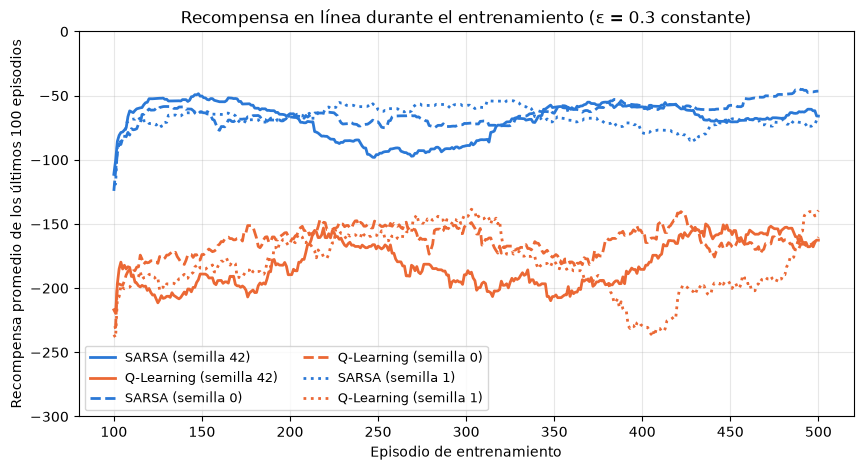

In [4]:
# Pregunta 3: registro de la recompensa acumulada promedio de los últimos 100
# episodios DURANTE el entrenamiento (con la exploración ε = 0.3 incluida), sin
# cambiar nada más del código original. entrenar() guarda ese promedio en cada
# episodio (prom100_sarsa / prom100_qlearning) y con registro_cada=100 lo imprime.

corridas_p3 = {}
for seed in SEMILLAS:
    print(f"=== Semilla {seed} (ε = {EPSILON} constante, α = {ALPHA}) ===")
    corridas_p3[seed] = entrenar(seed=seed, registro_cada=100)

resumen = pd.DataFrame({
    'SARSA: media 500 ep.': [R['rewards_sarsa'].mean() for R in corridas_p3.values()],
    'Q-L: media 500 ep.': [R['rewards_qlearning'].mean() for R in corridas_p3.values()],
    'SARSA: últ. 100': [R['prom100_sarsa'][-1] for R in corridas_p3.values()],
    'Q-L: últ. 100': [R['prom100_qlearning'][-1] for R in corridas_p3.values()],
    'SARSA: greedy final': [evaluate_policy(R['Q_sarsa']) for R in corridas_p3.values()],
    'Q-L: greedy final': [evaluate_policy(R['Q_qlearning']) for R in corridas_p3.values()],
}, index=pd.Index([f'semilla {s}' for s in SEMILLAS])).round(1)
resumen.loc['promedio'] = resumen.mean().round(1)
print("\nRecompensa EN LÍNEA (durante el entrenamiento) vs. recompensa de la política greedy final:")
display(resumen)

# Graficamos desde el episodio 100 (ventana de 100 episodios completa)
fig, ax = plt.subplots(figsize=(10, 5))
estilos = ['-', '--', ':']
episodios = np.arange(100, NUM_EPISODES + 1)
for (seed, R), ls in zip(corridas_p3.items(), estilos):
    ax.plot(episodios, R['prom100_sarsa'][99:], color=COLOR['SARSA'], ls=ls, lw=2,
            label=f'SARSA (semilla {seed})')
    ax.plot(episodios, R['prom100_qlearning'][99:], color=COLOR['Q-Learning'], ls=ls, lw=2,
            label=f'Q-Learning (semilla {seed})')
ax.set_ylim(-300, 0)
ax.set_xlabel('Episodio de entrenamiento')
ax.set_ylabel('Recompensa promedio de los últimos 100 episodios')
ax.set_title('Recompensa en línea durante el entrenamiento (ε = 0.3 constante)')
ax.grid(alpha=0.3)
ax.legend(ncol=2, fontsize=9)
plt.show()

**Respuesta**

**Resultado.** Durante el entrenamiento **SARSA obtiene siempre mejor recompensa en línea** que Q-Learning: en los 15 registros (cada 100 episodios × 3 semillas) el promedio de SARSA está por encima. Promediando las 3 corridas:

| | SARSA | Q-Learning |
|---|---:|---:|
| media de los 500 episodios | **−76.2** | −181.2 |
| últimos 100 episodios | **−59.6** | −154.1 |
| política greedy final | −200 / −200 / −17 | **−13 / −13 / −13** |

El gráfico muestra lo mismo: a partir del episodio 100 (ventana completa), la peor ventana de SARSA (−124.2) es mejor que la mejor ventana de Q-Learning (−138.5). Las curvas no se cruzan nunca.

**Por qué.** La recompensa en línea mide la política de **comportamiento** (ε-greedy con ε = 0.3), no la greedy.

- Q-Learning aprende $q_*$, cuya política greedy va pegada al acantilado (−13). Pero durante el entrenamiento ejecuta esa ruta con ε = 0.3: en cada paso por el borde elige "abajo" con probabilidad ε/4 = 0.075, así que al recorrer los 10 estados del borde la probabilidad de caer al menos una vez es $1 - 0.925^{10} \approx 54\%$. Cada caída suma −100 y lo devuelve al inicio. Q-Learning optimiza el retorno de una política (la greedy) que nunca ejecuta mientras entrena.
- SARSA aprende $q_\pi$ de la propia política ε-greedy. Las caídas que provoca su exploración aparecen en sus objetivos $r + \gamma Q(s',a')$, entonces aprende a alejarse del borde, a una zona donde una acción aleatoria cuesta un paso de más y no −100. Optimiza justo lo que se mide en línea.

**El costo de SARSA** aparece cuando se apaga la exploración: su política greedy es más larga (−17 en la semilla 1, contra −13 de Q-Learning) porque da un rodeo para cubrirse de un riesgo que con 100% greedy ya no existe. En las semillas 42 y 0 la política greedy final directamente no llega a la meta (−200, queda en un ciclo): con α = 0.5 y ε = 0.3 la Q-table de SARSA es muy ruidosa, y eso se corrige en la pregunta 7. En resumen, **SARSA es mejor "en línea" y Q-Learning es mejor "fuera de línea"**.

**4.** Imprima puntualmente los valores Q(36, a) para las 4 acciones posibles desde el estado inicial (36), en ambas tablas.

¿La acción con mayor valor Q en SARSA es la misma que en Q-Learning? ¿Cómo se relaciona esto con la primera decisión que toma cada agente al iniciar un episodio (alejarse de entrada del acantilado o intentar bordearlo)? (VALOR EJERCICIO 0.4)

In [5]:
# Pregunta 4: Q(36, a) para las 4 acciones desde el estado inicial, en ambas
# tablas (corridas de la configuración original, mismas 3 semillas). Agregamos los
# primeros pasos de la política greedy y Q(24, a), el estado al que lleva 'arriba'.

for seed, R in corridas_base.items():
    Qs, Qq = R['Q_sarsa'], R['Q_qlearning']
    print(f"=== Semilla {seed} ===")
    print(pd.DataFrame({'SARSA': Qs[START], 'Q-Learning': Qq[START]},
                       index=[f'Q(36,{n})' for n in NOMBRES]).T.round(1).to_string())
    print(f"  Acción de mayor Q en 36 -> SARSA: {NOMBRES[greedy(Qs, START)]}"
          f" | Q-Learning: {NOMBRES[greedy(Qq, START)]}")
    print(f"  Q(36, arriba) - Q(36, derecha) -> SARSA: {Qs[START, ARRIBA] - Qs[START, DERECHA]:.1f}"
          f" | Q-Learning: {Qq[START, ARRIBA] - Qq[START, DERECHA]:.1f}")
    print(f"  Q(24, ·) SARSA: {np.round(Qs[24], 1)} -> {NOMBRES[greedy(Qs, 24)]}"
          f" | Q-Learning: {np.round(Qq[24], 1)} -> {NOMBRES[greedy(Qq, 24)]}")
    print(f"  Primeros 5 estados greedy -> SARSA: {trayectoria_greedy(Qs)[:5]}"
          f" | Q-Learning: {trayectoria_greedy(Qq)[:5]}\n")

=== Semilla 42 ===
            Q(36,arriba)  Q(36,derecha)  Q(36,abajo)  Q(36,izquierda)
SARSA              -42.8         -148.5        -49.4            -48.2
Q-Learning         -13.0         -113.0        -14.0            -14.0
  Acción de mayor Q en 36 -> SARSA: arriba | Q-Learning: arriba
  Q(36, arriba) - Q(36, derecha) -> SARSA: 105.7 | Q-Learning: 100.0
  Q(24, ·) SARSA: [-40.5 -96.4 -49.4 -43.3] -> arriba | Q-Learning: [-14. -12. -14. -13.] -> derecha
  Primeros 5 estados greedy -> SARSA: [36, 24, 12, 0, 1] | Q-Learning: [36, 24, 25, 26, 27]

=== Semilla 0 ===
            Q(36,arriba)  Q(36,derecha)  Q(36,abajo)  Q(36,izquierda)
SARSA              -33.4         -177.1        -97.7           -112.0
Q-Learning         -13.0         -113.0        -14.0            -14.0
  Acción de mayor Q en 36 -> SARSA: arriba | Q-Learning: arriba
  Q(36, arriba) - Q(36, derecha) -> SARSA: 143.7 | Q-Learning: 100.0
  Q(24, ·) SARSA: [-37.7 -32.  -51.6 -38.2] -> derecha | Q-Learning: [-14. -12. -14

**Respuesta**

**Sí, en las 3 corridas la acción de mayor valor en el estado 36 es la misma: "arriba".**

| | arriba | derecha | abajo | izquierda |
|---|---:|---:|---:|---:|
| Q-Learning (las 3 semillas) | **−13.0** | −113.0 | −14.0 | −14.0 |
| SARSA semilla 42 | **−42.8** | −148.5 | −49.4 | −48.2 |
| SARSA semilla 0 | **−33.4** | −177.1 | −97.7 | −112.0 |
| SARSA semilla 1 | **−44.6** | −164.4 | −64.7 | −56.0 |

**Por qué coinciden.** Desde 36, "derecha" cae directo al acantilado (37), y "abajo" o "izquierda" chocan contra la pared y gastan un paso sin avanzar. La única primera acción útil es subir, para los dos. La primera decisión no separa "alejarse" de "bordear". La diferencia aparece en **cuánto** vale subir y en **la segunda decisión**:

- **Q-Learning** valora "arriba" en −13: supone que después va a seguir el camino greedy de 12 pasos más por el borde. En 24 su mejor acción es "derecha" ($Q(24,\cdot) = [-14, -12, -14, -13]$) y la trayectoria greedy es 36 → 24 → 25 → 26 → 27…, **bordea** el acantilado. Además, $Q(36,\text{arriba}) - Q(36,\text{derecha}) = 100$ exacto: sólo los separa el −100 de la caída, porque después de caer vuelve a 36 y la continuación óptima es la misma.
- **SARSA** valora "arriba" entre −33 y −45, porque ese valor incluye el costo esperado de seguir explorando. Su trayectoria greedy **se aleja del borde**: en la semilla 42 sube directamente hasta la fila de arriba (36 → 24 → 12 → 0), y en las semillas 0 y 1 da un paso a la derecha y enseguida sube (36 → 24 → 25 → 13 → 1). La brecha entre "arriba" y "derecha" en 36 también es mayor (105.7 / 143.7 / 119.8), porque para SARSA caer implica volver a un inicio que, explorando, vale bastante menos que −13.

En resumen, la primera acción es la misma, pero lo que cada agente "espera" al tomarla es distinto. Q-Learning sube para bordear el acantilado por el camino más corto y SARSA sube para alejarse de él.

**5.** Durante los primeros episodios de entrenamiento, con `EPSILON` alto, ambos agentes caen muchas veces al acantilado. Inspeccione cómo cambia con las corridas el valor Q(s, "abajo") de un estado cercano al acantilado en `Q_qlearning` a medida que aumenta la cantidad de episodios (imprímalo, por ejemplo, cada 100 episodios).

¿Ese valor queda "marcado" para siempre por las malas experiencias iniciales, o el algoritmo logra corregirlo a medida que seguimos actualizando Q? Justifique la respuesta observando la ecuación de actualización de Q-Learning. (VALOR EJERCICIO 0.4)

Q-Learning: Q(30, 'abajo') y el valor del estado inicial a lo largo del entrenamiento
(primeros episodios y luego cada 100):


semilla 42                 semilla 0                 semilla 1  \
         Q(30,abajo) max_a Q(36,a) Q(30,abajo) max_a Q(36,a) Q(30,abajo)   
episodio                                                                   
1                0.0           0.0         0.0           0.0         0.0   
2              -77.6          -4.4       -78.0          -5.2       -77.9   
3              -91.5          -6.1       -78.0          -5.5       -77.9   
5              -91.5          -6.9       -91.9          -6.0       -98.5   
10             -99.6          -9.0      -103.5          -8.0      -102.9   
20            -107.5         -10.7      -108.9         -10.3      -102.9   
50            -112.1         -13.0      -111.6         -13.0      -112.0   
100           -113.0         -13.0      -113.0         -13.0      -113.0   
200           -113.0         -13.0      -113.0         -13.0      -113.0   
300           -113.0         -13.0      -113.0         -13.0      -113.0   
400           -113.0         -13.0      -113.0         -13.0      -113.0   
500           -113.0         -13.0      -113.0         -13.0      -113.0   
600           -113.0         -13.0      -113.0         -13.0      -113.0   
700           -113.0         -13.0      -113.0         -13.0      -113.0   
800           -113.0         -13.0      -113.0         -13.0      -113.0   
900           -113.0         -13.0      -113.0         -13.0      -113.0   
1000          -113.0         -13.0      -113.0         -13.0      -113.0   

                        
         max_a Q(36,a)  
episodio                
1                  0.0  
2                 -4.6  
3                 -5.0  
5                 -6.1  
10                -7.5  
20                -9.8  
50               -13.0  
100              -13.0  
200              -13.0  
300              -13.0  
400              -13.0  
500              -13.0  
600              -13.0  
700              -13.0  
800              -13.0  
900              -13.0  
1000             -13.0

Valor esperado si Q-Learning convergió: q*(s, abajo) = -100 + max_a q*(36, a) = -100 + (-13) = -113
Peso que conserva una experiencia vieja tras n actualizaciones, (1 - α)^n con α = 0.5: n=1: 0.5000, n=5: 0.0312, n=10: 0.0010, n=20: 0.0000

SARSA, mismo estado: Q(30, 'abajo') en los episodios 500..1000 (cada 100):
  semilla 42: [-165.  -154.6 -154.6 -154.6 -154.6 -154.6]
  semilla  0: [-133.7 -133.7 -137.1 -137.1 -137.1 -137.1]
  semilla  1: [-199.  -199.  -188.9 -188.9 -188.9 -188.9]


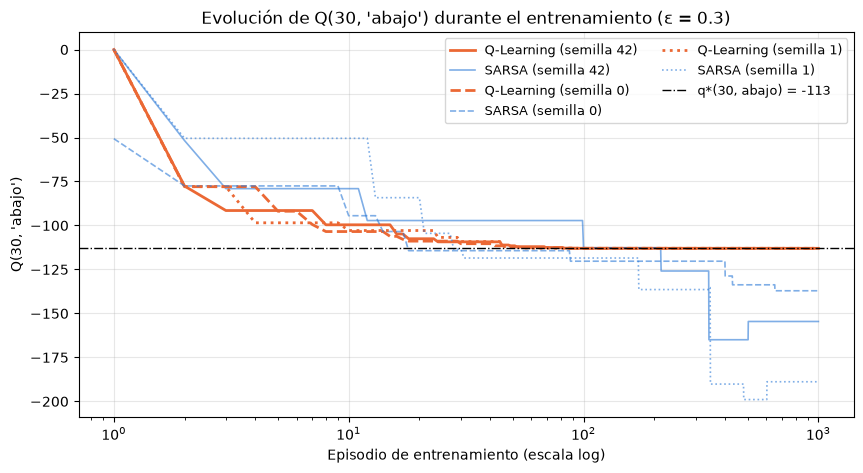

In [6]:
# Pregunta 5: evolución de Q_qlearning[s]['abajo'] para un estado pegado al
# acantilado (s = 30: fila 2, columna 6). Entrenamos 1000 episodios (el doble que
# el original) con ε = 0.3 constante y guardamos una copia de Q en cada episodio.
S_OBS = 30
N_EP_P5 = 1000
corridas_p5 = {seed: entrenar(num_episodes=N_EP_P5, seed=seed, snapshot_cada=1) for seed in SEMILLAS}

def serie(R, algoritmo, s, a):
    idx = 2 if algoritmo == 'Q-Learning' else 1
    return np.array([snap[idx][s, a] for snap in R['snapshots']])

checkpoints = [1, 2, 3, 5, 10, 20, 50] + list(range(100, N_EP_P5 + 1, 100))
tabla = {}
for seed, R in corridas_p5.items():
    q_abajo = serie(R, 'Q-Learning', S_OBS, ABAJO)
    v_inicio = np.array([snap[2][START].max() for snap in R['snapshots']])
    tabla[(f'semilla {seed}', f'Q({S_OBS},abajo)')] = q_abajo[np.array(checkpoints) - 1]
    tabla[(f'semilla {seed}', 'max_a Q(36,a)')] = v_inicio[np.array(checkpoints) - 1]
df_p5 = pd.DataFrame(tabla, index=pd.Index(checkpoints, name='episodio')).round(1)
print(f"Q-Learning: Q({S_OBS}, 'abajo') y el valor del estado inicial a lo largo del entrenamiento")
print("(primeros episodios y luego cada 100):")
display(df_p5)

print("Valor esperado si Q-Learning convergió: q*(s, abajo) = -100 + max_a q*(36, a) = -100 + (-13) = -113")
print(f"Peso que conserva una experiencia vieja tras n actualizaciones, (1 - α)^n con α = {ALPHA}: "
      + ", ".join(f"n={n}: {(1 - ALPHA) ** n:.4f}" for n in [1, 5, 10, 20]))

# Contraste: el mismo valor en SARSA (no converge a un número fijo con ε = 0.3)
print(f"\nSARSA, mismo estado: Q({S_OBS}, 'abajo') en los episodios 500..1000 (cada 100):")
for seed, R in corridas_p5.items():
    s_abajo = serie(R, 'SARSA', S_OBS, ABAJO)
    print(f"  semilla {seed:2d}: {np.round(s_abajo[499::100], 1)}")

fig, ax = plt.subplots(figsize=(10, 5))
eps_x = np.arange(1, N_EP_P5 + 1)
for (seed, R), ls in zip(corridas_p5.items(), ['-', '--', ':']):
    ax.plot(eps_x, serie(R, 'Q-Learning', S_OBS, ABAJO), color=COLOR['Q-Learning'], ls=ls, lw=2,
            label=f'Q-Learning (semilla {seed})')
    ax.plot(eps_x, serie(R, 'SARSA', S_OBS, ABAJO), color=COLOR['SARSA'], ls=ls, lw=1.2, alpha=0.6,
            label=f'SARSA (semilla {seed})')
ax.axhline(-113, color='black', lw=1, ls='-.', label='q*(30, abajo) = -113')
ax.set_xscale('log')
ax.set_xlabel('Episodio de entrenamiento (escala log)')
ax.set_ylabel(f"Q({S_OBS}, 'abajo')")
ax.set_title(f"Evolución de Q({S_OBS}, 'abajo') durante el entrenamiento (ε = 0.3)")
ax.grid(alpha=0.3)
ax.legend(ncol=2, fontsize=9)
plt.show()

**Respuesta**

**No queda marcado: Q-Learning lo corrige y converge al valor correcto.** En las 3 corridas, $Q_{QL}(30,\text{abajo})$ arranca en 0, baja a −77.6 / −78.0 / −77.9 en el episodio 2, sigue a −99.6 / −103.5 / −102.9 en el episodio 10 y a −112.1 / −111.6 / −112.0 en el 50, y **desde el episodio 100 queda clavado en −113.0** en todos los registros (100, 200, …, 1000). Al mismo tiempo, $\max_a Q(36,a)$ va de 0 a −13.0 (episodio 50).

Ese −113 no es una "mancha" de las primeras caídas, sino $q_*(30,\text{abajo}) = -100 + \max_a q_*(36,a) = -100 - 13$: la caída más el camino óptimo desde el inicio. Bajar desde el borde *es* malo, y lo que el algoritmo ajusta es *cuánto*. De hecho, los valores de los primeros episodios eran **menos** negativos que el final, porque al principio $\max_a Q(36,a)$ era optimista (cerca de 0).

**Justificación con la ecuación de actualización.**

$$Q(s,a) \leftarrow (1-\alpha)\,Q(s,a) + \alpha\,\big[\,r + \gamma \max_{a'} Q(s',a')\,\big]$$

1. **α constante = promedio con olvido exponencial.** Desarrollando la recursión, un valor (o un objetivo) de hace $n$ actualizaciones pesa $(1-\alpha)^n$. Con α = 0.5: 0.5 después de 1 actualización, 0.031 después de 5 y 0.001 después de 10. Las experiencias viejas se olvidan rápido.
2. **El objetivo no depende de lo que hizo la exploración.** Para (30, abajo) el objetivo es siempre $-100 + \gamma \max_{a'} Q(36,a')$: la recompensa es fija y el $\max$ ignora qué acción eligió después la política de comportamiento. Cuando $\max_a Q(36,a)$ converge a −13, el objetivo es la constante −113 y el valor converge exactamente a eso, sin importar cuántas veces se haya caído antes ni con qué ε se explore. Es la propiedad off-policy: Q-Learning converge a $q_*$ con cualquier política de comportamiento que siga visitando todos los pares.

**Contraste con SARSA** (mismo estado, mismas corridas): su $Q(30,\text{abajo})$ no se estabiliza en un valor fijo. Entre el episodio 500 y el 1000 pasa de −165.0 a −154.6, de −133.7 a −137.1 y de −199.0 a −188.9, según la semilla. Su objetivo $-100 + \gamma Q(36,a')$ depende de la $a'$ que se muestree en cada visita y de un $Q_{sarsa}(36,\cdot)$ que también es ruidoso, así que cada visita lo mueve a un lugar distinto. En el gráfico se ve que las curvas de Q-Learning se juntan en −113 y las de SARSA quedan dispersas.

**6.** Modifique la función `evaluate_policy` para que, en lugar de actuar 100% greedy, la evaluación final se haga con una política ε-greedy residual (por ejemplo `epsilon=0.05`), igual que hace la política de comportamiento durante el entrenamiento.

¿Qué le pasa a la recompensa obtenida por la política de Q-Learning frente a la de SARSA cuando queda algo de exploración residual en la evaluación? ¿Por qué SARSA resulta más robusto ante este tipo de evaluación que Q-Learning? (VALOR EJERCICIO 0.4)

In [7]:
# Pregunta 6: evaluate_policy modificada para evaluar con una política ε-greedy
# residual (ε = 0.05) en lugar de 100% greedy. Como con ε > 0 el resultado es
# aleatorio, promediamos 1000 episodios de evaluación y además contamos en qué
# fracción de episodios el agente cae al acantilado al menos una vez.

def evaluate_policy(Q, n_eval=1000, max_steps=200, epsilon=0.05, seed=None, detalle=False):
    """Ejecuta la política ε-greedy (ε residual) y devuelve la recompensa media.
    Con detalle=True devuelve (recompensa media, % episodios con caída, % episodios cortados)."""
    if seed is not None:
        np.random.seed(seed)
    total, con_caida, cortados = 0.0, 0, 0
    for _ in range(n_eval):
        state, _ = env.reset()
        done, steps, cayo = False, 0, False
        while not done and steps < max_steps:
            action = epsilon_greedy(Q, state, epsilon)   # <-- antes: greedy(Q, state)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total += reward
            cayo = cayo or (reward == -100)
            steps += 1
        con_caida += cayo
        cortados += not done
    media = total / n_eval
    return (media, con_caida / n_eval, cortados / n_eval) if detalle else media

# Evaluamos las Q-tables de la configuración original (las mismas de P1, P3 y P4)
EPS_EVAL = [0.0, 0.05, 0.1]
filas = []
for seed, R in corridas_base.items():
    for alg, Q in [('SARSA', R['Q_sarsa']), ('Q-Learning', R['Q_qlearning'])]:
        fila = {'semilla': seed, 'algoritmo': alg}
        for e in EPS_EVAL:
            media, caida, cortados = evaluate_policy(Q, epsilon=e, n_eval=1000, seed=seed, detalle=True)
            fila[f'recompensa ε={e}'] = round(media, 1)
            fila[f'% con caída ε={e}'] = round(100 * caida, 1)
            fila[f'% cortados ε={e}'] = round(100 * cortados, 1)
        filas.append(fila)
df_p6 = pd.DataFrame(filas).set_index(['semilla', 'algoritmo'])
print("Evaluación de las políticas finales (1000 episodios, max_steps = 200):")
display(df_p6)
print("Promedio sobre las 3 semillas:")
display(df_p6.groupby(level='algoritmo').mean().round(1))

Evaluación de las políticas finales (1000 episodios, max_steps = 200):


recompensa ε=0.0  % con caída ε=0.0  % cortados ε=0.0  \
semilla algoritmo                                                           
42      SARSA                 -200.0                0.0             100.0   
        Q-Learning             -13.0                0.0               0.0   
0       SARSA                 -200.0                0.0             100.0   
        Q-Learning             -13.0                0.0               0.0   
1       SARSA                  -17.0                0.0               0.0   
        Q-Learning             -13.0                0.0               0.0   

                    recompensa ε=0.05  % con caída ε=0.05  % cortados ε=0.05  \
semilla algoritmo                                                              
42      SARSA                  -190.6                 1.6               82.0   
        Q-Learning              -30.1                13.3                0.0   
0       SARSA                   -95.5                 2.5               11.0   
        Q-Learning              -29.5                12.7                0.0   
1       SARSA                   -22.7                 3.1                0.0   
        Q-Learning              -29.4                13.2                0.0   

                    recompensa ε=0.1  % con caída ε=0.1  % cortados ε=0.1  
semilla algoritmo                                                          
42      SARSA                 -168.0                4.3              51.3  
        Q-Learning             -50.8               25.3               0.0  
0       SARSA                  -67.4                6.3               1.2  
        Q-Learning             -50.2               25.9               0.0  
1       SARSA                  -27.3                5.9               0.0  
        Q-Learning             -48.3               24.4               0.0

Promedio sobre las 3 semillas:


,recompensa ε=0.0,% con caída ε=0.0,% cortados ε=0.0,recompensa ε=0.05,% con caída ε=0.05,% cortados ε=0.05,recompensa ε=0.1,% con caída ε=0.1,% cortados ε=0.1
algoritmo,,,,,,,,,
Q-Learning,-13.0,0.0,0.0,-29.7,13.1,0.0,-49.8,25.2,0.0
SARSA,-139.0,0.0,66.7,-102.9,2.4,31.0,-87.6,5.5,17.5


**Respuesta**

**Resultado** (1000 episodios de evaluación, promedio de las 3 semillas):

| | greedy (ε = 0) | ε = 0.05 | ε = 0.1 |
|---|---:|---:|---:|
| Q-Learning: recompensa | −13.0 | −29.7 | −49.8 |
| Q-Learning: % episodios con caída | 0.0 | **13.1** | **25.2** |
| SARSA: % episodios con caída | 0.0 | **2.4** | **5.5** |

Con un poco de exploración residual, **Q-Learning pierde mucho**: la recompensa pasa de −13 a ≈ −30 (más del doble) y se cae en 1 de cada 8 episodios (13.1%). SARSA casi no se cae (2.4%). En la semilla 1, la única donde la política greedy de SARSA del entrenamiento original llega a la meta, SARSA pasa de −17.0 a −22.7 (pierde 5.7 puntos) y Q-Learning de −13.0 a −29.4 (pierde 16.4). **Con ε = 0.05 SARSA ya obtiene mejor recompensa que Q-Learning**, y con ε = 0.1 la diferencia crece (−27.3 contra −48.3).

**Por qué Q-Learning sufre tanto.** Su política greedy es óptima *sólo si se ejecuta sin errores*: recorre los 10 estados del borde, y con ε = 0.05 en cada uno elige "abajo" con probabilidad ε/4 = 0.0125. La probabilidad de caer en un recorrido es $1 - 0.9875^{10} \approx 11.8\%$, más 1.25% de caer desde el propio 36 con "derecha": ≈ 13%, lo mismo que se midió (13.1%). Con ε = 0.1 la cuenta da ≈ 25%, y se midió 25.2%. Cada caída cuesta −100 más volver a empezar, ≈ −113. Q-Learning nunca incorporó ese riesgo porque su objetivo $\max_{a'} Q(s',a')$ supone que nunca se va a equivocar.

**Por qué SARSA es más robusto.** SARSA aprendió el valor de una política que **sí comete errores aleatorios**, porque su objetivo $r + \gamma Q(s',a')$ usa la acción que realmente eligió la ε-greedy. Su política greedy ya deja margen respecto del acantilado, y ahí una acción aleatoria cuesta uno o dos pasos y no −100. Evaluarlo con ε residual se parece a las condiciones para las que fue entrenado.

**Detalle sobre las semillas 42 y 0.** Ahí la recompensa media de SARSA es mala (−190.6 y −95.5 con ε = 0.05), pero no por el acantilado (se cae en 1.6% y 2.5% de los episodios). Su política greedy tiene **ciclos**: con ε = 0, el 100% de los episodios se corta a los 200 pasos, y el ruido de ε a veces rompe el ciclo (por eso mejora al subir ε). Es un problema de convergencia de SARSA con α = 0.5 que se corrige en la pregunta 7. Con los agentes ajustados de la pregunta 7 la comparación queda limpia: con ε = 0.05 SARSA obtiene −19.1 / −18.8 / −19.8 (se cae en 0.7–1.7% de los episodios) y Q-Learning −31.5 / −30.2 / −30.8 (13.2–14.0%).

**7.** Ajuste los hiperparámetros que considere necesarios (inicialización de Q, `ALPHA`, `EPSILON` y/o un esquema de decaimiento, `NUM_EPISODES`) hasta lograr que **ambos** algoritmos aprendan una política razonable. Imprima entonces la Q-table completa de ambos y, para cada estado de la fila adyacente al acantilado, identifique cuál es la acción con mayor valor Q en cada tabla.

Con esa evidencia concreta (los valores de la Q-table, no solo el dibujo de la política), explique en sus propias palabras por qué SARSA, al ser **on-policy**, "sabe" que va a seguir explorando ocasionalmente y por eso penaliza más los estados cercanos al precipicio, mientras que Q-Learning, al ser **off-policy**, asume que de ahora en más actuará siempre de forma greedy y por eso no penaliza esos estados de la misma manera. (VALOR EJERCICIO 0.9)

=== Semilla 42 ===


  Ep  500 | ε=0.184 | SARSA (últ. 100):   -27.1 | Q-Learning (últ. 100):   -86.2


  Ep 1000 | ε=0.100 | SARSA (últ. 100):   -22.6 | Q-Learning (últ. 100):   -72.7


  Ep 1500 | ε=0.100 | SARSA (últ. 100):   -22.9 | Q-Learning (últ. 100):   -45.4


  Ep 2000 | ε=0.100 | SARSA (últ. 100):   -19.6 | Q-Learning (últ. 100):   -38.0


...

,argmax SARSA,argmax Q-L,SARSA arriba,SARSA derecha,SARSA abajo,Q-L arriba,Q-L derecha,Q-L abajo
estado,,,,,,,,
24,arriba,derecha,-19.3,-27.3,-24.3,-13.9,-12.0,-14.0
25,izquierda,derecha,-21.7,-21.1,-119.4,-13.0,-11.0,-113.0
26,izquierda,derecha,-12.7,-19.4,-107.5,-12.0,-10.0,-113.0
27,arriba,derecha,-12.6,-12.7,-98.9,-11.0,-9.0,-113.0
28,derecha,derecha,-13.0,-12.7,-113.8,-10.0,-8.0,-113.0
29,arriba,derecha,-13.7,-13.7,-96.9,-9.0,-7.0,-113.0
30,arriba,derecha,-13.1,-16.6,-90.2,-8.0,-6.0,-113.0
31,izquierda,derecha,-10.6,-11.8,-86.0,-7.0,-5.0,-113.0
32,arriba,derecha,-10.5,-13.6,-73.1,-6.0,-4.0,-113.0


  Promedio en estados 25-34 -> SARSA: Q(s,derecha) = -14.3, Q(s,abajo) = -99.7 | Q-Learning: Q(s,derecha) = -6.5, Q(s,abajo) = -113.0
  Estados 25-34 con 'arriba' como mejor acción -> SARSA: 6/10 | Q-Learning: 0/10
  Punto fijo de Q(s,abajo): Q-Learning -100 + max_a Q(36,a) = -113.0 | SARSA -100 + E_ε[Q(36,a')] (ε = 0.1) = -124.0
  Veces que se ejecutó (s, abajo) en 25-34 durante el entrenamiento -> SARSA: 161 | Q-Learning: 1231

Fila adyacente al acantilado — semilla 1:


,argmax SARSA,argmax Q-L,SARSA arriba,SARSA derecha,SARSA abajo,Q-L arriba,Q-L derecha,Q-L abajo
estado,,,,,,,,
24,arriba,derecha,-18.4,-19.7,-34.1,-13.9,-12.0,-14.0
25,arriba,derecha,-18.0,-21.5,-121.3,-13.0,-11.0,-113.0
26,arriba,derecha,-17.0,-18.3,-115.8,-12.0,-10.0,-113.0
27,izquierda,derecha,-15.7,-19.4,-94.9,-11.0,-9.0,-113.0
28,arriba,derecha,-13.5,-14.7,-92.2,-10.0,-8.0,-113.0
29,izquierda,derecha,-12.9,-14.5,-80.3,-9.0,-7.0,-113.0
30,arriba,derecha,-8.4,-13.1,-90.5,-8.0,-6.0,-113.0
31,arriba,derecha,-10.7,-11.0,-93.0,-7.0,-5.0,-113.0
32,izquierda,derecha,-13.5,-17.2,-89.1,-6.0,-4.0,-113.0


  Promedio en estados 25-34 -> SARSA: Q(s,derecha) = -14.2, Q(s,abajo) = -95.6 | Q-Learning: Q(s,derecha) = -6.5, Q(s,abajo) = -113.0
  Estados 25-34 con 'arriba' como mejor acción -> SARSA: 6/10 | Q-Learning: 0/10
  Punto fijo de Q(s,abajo): Q-Learning -100 + max_a Q(36,a) = -113.0 | SARSA -100 + E_ε[Q(36,a')] (ε = 0.1) = -122.6
  Veces que se ejecutó (s, abajo) en 25-34 durante el entrenamiento -> SARSA: 147 | Q-Learning: 1230

V(s) promedio por fila (columnas 1-10). La fila 2 es la pegada al acantilado:


fila 0  fila 1  fila 2  fila 2 - fila 0
algoritmo  semilla                                         
Q-Learning 0          -8.0    -7.5    -6.5              1.5
           1          -8.0    -7.5    -6.5              1.5
           42         -8.0    -7.5    -6.5              1.5
SARSA      0         -10.2   -11.2   -11.9             -1.7
           1          -9.6   -10.3   -11.8             -2.2
           42         -9.5   -10.1   -11.7             -2.2

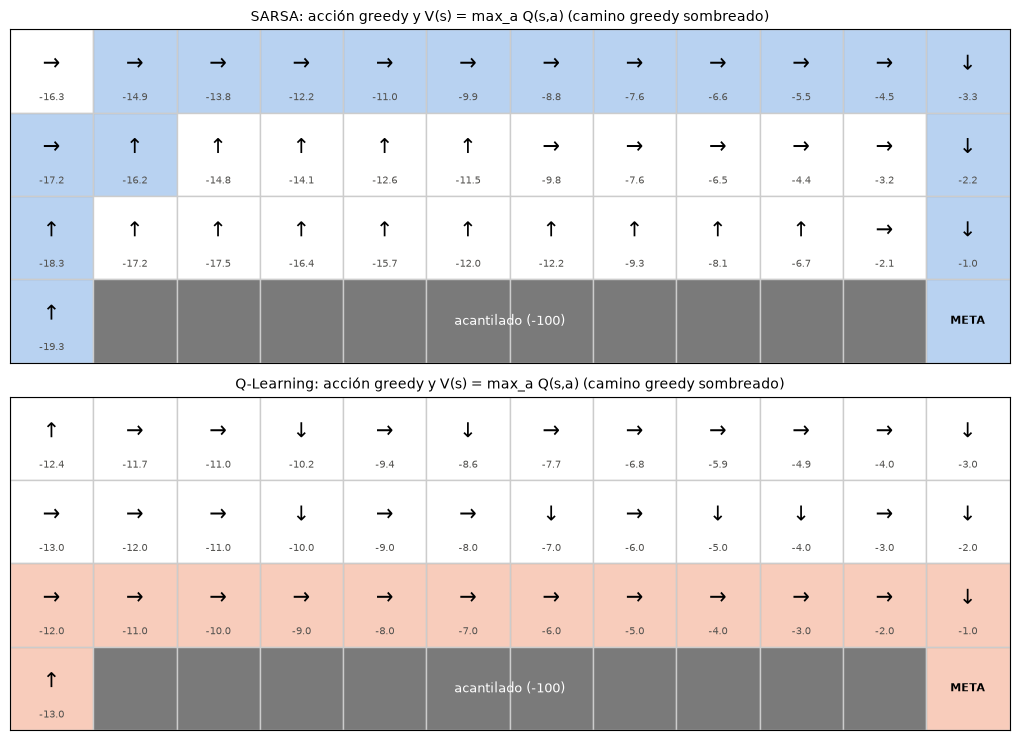

In [8]:
# Pregunta 7: ajuste de hiperparámetros para que AMBOS aprendan una política razonable.
#  - ALPHA 0.5 -> 0.1: el objetivo de SARSA es ruidoso (depende de la a' muestreada);
#    con α = 0.5 un par de experiencias recientes dominan Q y la política greedy
#    queda con ciclos (recompensa -200 en P1). Con α chico Q promedia muchas muestras.
#  - ε con decaimiento 0.5 -> 0.1 (EPSILON_DECAY = 0.998, llega al piso en ~800 ep.):
#    mucha exploración al principio y un piso de 0.1 (no 0) para que el agente
#    siga explorando, como en el ejemplo 6.6 de Sutton & Barto.
#  - NUM_EPISODES 500 -> 2000 para compensar el α más chico.
#  - Q inicial en 0 (ya es optimista: todas las recompensas son negativas).
NUM_EPISODES_P7 = 2000
ALPHA_P7 = 0.1
EPSILON_START_P7 = 0.5
EPSILON_MIN_P7 = 0.1
EPSILON_DECAY_P7 = 0.998
Q_INIT_P7 = 0.0

corridas_p7 = {}
for seed in SEMILLAS:
    print(f"=== Semilla {seed} ===")
    R = entrenar(num_episodes=NUM_EPISODES_P7, alpha=ALPHA_P7, epsilon=EPSILON_START_P7,
                 epsilon_min=EPSILON_MIN_P7, epsilon_decay=EPSILON_DECAY_P7,
                 q_init=Q_INIT_P7, seed=seed, registro_cada=500)
    corridas_p7[seed] = R
    for alg, Q in [('SARSA', R['Q_sarsa']), ('Q-Learning', R['Q_qlearning'])]:
        g = evaluate_policy(Q, epsilon=0.0, n_eval=1)
        r05, caida, _ = evaluate_policy(Q, epsilon=0.05, n_eval=1000, seed=seed, detalle=True)
        print(f"  {alg:10s} | greedy: {g:6.1f} | ε-greedy 0.05: {r05:6.1f} (cae en {100*caida:4.1f}% de los ep.)"
              f" | camino greedy: {trayectoria_greedy(Q)}")

print("\nQ-tables completas (semilla 42):")
display(tabla_q(corridas_p7[42]['Q_sarsa'], corridas_p7[42]['Q_qlearning']))

# Fila adyacente al acantilado (fila 2: estados 24 a 35): acción de mayor Q en cada tabla
FILA_2 = list(range(24, 36))
for seed, R in corridas_p7.items():
    Qs, Qq = R['Q_sarsa'], R['Q_qlearning']
    df = pd.DataFrame({
        'argmax SARSA': [NOMBRES[greedy(Qs, s)] for s in FILA_2],
        'argmax Q-L': [NOMBRES[greedy(Qq, s)] for s in FILA_2],
        'SARSA arriba': Qs[FILA_2, ARRIBA], 'SARSA derecha': Qs[FILA_2, DERECHA],
        'SARSA abajo': Qs[FILA_2, ABAJO],
        'Q-L arriba': Qq[FILA_2, ARRIBA], 'Q-L derecha': Qq[FILA_2, DERECHA],
        'Q-L abajo': Qq[FILA_2, ABAJO],
    }, index=pd.Index(FILA_2, name='estado')).round(1)
    print(f"\nFila adyacente al acantilado — semilla {seed}:")
    display(df)
    borde = np.array(FILA_BORDE)
    print(f"  Promedio en estados 25-34 -> SARSA: Q(s,derecha) = {Qs[borde, DERECHA].mean():.1f}, "
          f"Q(s,abajo) = {Qs[borde, ABAJO].mean():.1f} | Q-Learning: Q(s,derecha) = {Qq[borde, DERECHA].mean():.1f}, "
          f"Q(s,abajo) = {Qq[borde, ABAJO].mean():.1f}")
    print(f"  Estados 25-34 con 'arriba' como mejor acción -> SARSA: {sum(greedy(Qs, s) == ARRIBA for s in borde)}/10"
          f" | Q-Learning: {sum(greedy(Qq, s) == ARRIBA for s in borde)}/10")
    print(f"  Punto fijo de Q(s,abajo): Q-Learning -100 + max_a Q(36,a) = {-100 + Qq[START].max():.1f}"
          f" | SARSA -100 + E_ε[Q(36,a')] (ε = {EPSILON_MIN_P7}) = {-100 + esperanza_eps_greedy(Qs, START, EPSILON_MIN_P7):.1f}")
    print(f"  Veces que se ejecutó (s, abajo) en 25-34 durante el entrenamiento -> "
          f"SARSA: {R['visitas_sarsa'][borde, ABAJO].sum()} | Q-Learning: {R['visitas_qlearning'][borde, ABAJO].sum()}")

# ¿Cuánto vale estar en cada fila? V(s) = max_a Q(s,a) promediado en las columnas 1 a 10.
# Cuanto más abajo la fila, más cerca de la meta (1 paso menos por fila).
filas_v = []
for seed, R in corridas_p7.items():
    for alg, Q in [('SARSA', R['Q_sarsa']), ('Q-Learning', R['Q_qlearning'])]:
        V = Q.max(axis=1)
        filas_v.append({'algoritmo': alg, 'semilla': seed,
                        **{f'fila {f}': V[[f * N_COLS + c for c in range(1, 11)]].mean() for f in range(3)}})
df_v = pd.DataFrame(filas_v).set_index(['algoritmo', 'semilla']).sort_index().round(1)
df_v['fila 2 - fila 0'] = (df_v['fila 2'] - df_v['fila 0']).round(1)
print("\nV(s) promedio por fila (columnas 1-10). La fila 2 es la pegada al acantilado:")
display(df_v)

# Gráfico de las políticas aprendidas (semilla 42): flecha greedy y V(s) = max_a Q(s,a)
def dibujar_politica(ax, Q, nombre):
    camino = set(trayectoria_greedy(Q))
    for s in range(N_STATES):
        fila, col = divmod(s, N_COLS)
        if s in CLIFF:
            fc = '#7a7a7a'
        elif s in camino or s == GOAL:
            fc = COLOR[nombre] + '55'
        else:
            fc = 'white'
        ax.add_patch(plt.Rectangle((col, fila), 1, 1, facecolor=fc, edgecolor='#cccccc'))
        if s in CLIFF:
            continue
        if s == GOAL:
            ax.text(col + 0.5, fila + 0.5, 'META', ha='center', va='center', fontsize=8, weight='bold')
            continue
        ax.text(col + 0.5, fila + 0.42, ARROWS[greedy(Q, s)], ha='center', va='center', fontsize=15)
        ax.text(col + 0.5, fila + 0.82, f'{Q[s].max():.1f}', ha='center', va='center', fontsize=7, color='#52514e')
    ax.text(6, 3.5, 'acantilado (-100)', ha='center', va='center', color='white', fontsize=9)
    ax.set_xlim(0, N_COLS); ax.set_ylim(N_ROWS, 0)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect('equal')
    ax.set_title(f'{nombre}: acción greedy y V(s) = max_a Q(s,a) (camino greedy sombreado)', fontsize=10)

fig, axes = plt.subplots(2, 1, figsize=(11, 7.5))
dibujar_politica(axes[0], corridas_p7[42]['Q_sarsa'], 'SARSA')
dibujar_politica(axes[1], corridas_p7[42]['Q_qlearning'], 'Q-Learning')
plt.tight_layout()
plt.show()

**Respuesta**

**Ajustes y por qué.**

| Hiperparámetro | Original | Ajustado | Motivo |
|---|---|---|---|
| `ALPHA` | 0.5 | **0.1** | El objetivo de SARSA es ruidoso (depende de la $a'$ muestreada). Con α = 0.5 las últimas muestras dominan $Q$ y la greedy quedaba con ciclos (−200 en 2 de 3 semillas). Con α = 0.1, $Q$ promedia muchas más muestras. |
| `EPSILON` | 0.3 constante | **0.5 → 0.1** (decay 0.998, llega al piso en ~800 ep.) | Mucha exploración al principio y un **piso de 0.1**, no 0: el agente sigue explorando, como en el ejemplo 6.6 de Sutton & Barto. Si ε → 0, SARSA termina igual que Q-Learning (pregunta 2). |
| `NUM_EPISODES` | 500 | **2000** | Compensa el α más chico. |
| Q inicial | 0 | 0 | Ya es optimista (todas las recompensas son ≤ −1). |

**Resultado (3 semillas).** Ahora **los dos aprenden una política razonable en las 3 corridas**. SARSA llega a la meta con **−17**: sube hasta la fila de arriba, la recorre y baja recién al final (por ejemplo 36 → 24 → 12 → 0 → 1 → … → 11 → 23 → 35 → 47). Q-Learning llega con **−13** por el borde. En línea, durante los últimos 100 episodios, SARSA obtiene −19.6 / −22.6 / −20.1 y Q-Learning −38.0 / −41.0 / −54.1. Con evaluación ε-greedy (ε = 0.05), SARSA obtiene ≈ −19 y Q-Learning ≈ −31.

**Evidencia en las Q-tables (fila adyacente al acantilado, estados 24 a 35).**

- **Acción de mayor Q.** En Q-Learning es **"derecha" en los 11 estados de 24 a 34** (y "abajo" en 35, que lleva a la meta), en las 3 semillas. En SARSA es **"arriba" en 9 de 10** estados del borde en la semilla 42 y en 6 de 10 en las semillas 0 y 1. En los demás aparece "izquierda" o "derecha", siempre en estados que el camino greedy de SARSA no recorre. Por ejemplo, en 34 "derecha" lleva al agente al lado de la meta. En ningún caso es "abajo".
- **$Q(s,\text{derecha})$ en el borde** (seguir bordeando): en Q-Learning vale exactamente −11, −10, …, −2 para los estados 25 a 34, que es la cantidad de pasos que faltan, o sea $q_*$, sin ningún recargo por el acantilado (promedio −6.5). En SARSA promedia **−17.2 / −14.3 / −14.2**. Por ejemplo, en el estado 30: $Q_{sarsa}(30,\cdot) = [-12.2,\,-25.4,\,-87.5,\,-22.3]$ contra $Q_{QL}(30,\cdot) = [-8,\,-6,\,-113,\,-8]$. Para SARSA, seguir por el borde cuesta entre ≈ 8 y 11 puntos más que los pasos que faltan.
- **Cuánto vale estar en cada fila** ($V(s)=\max_a Q(s,a)$, promedio en las columnas 1 a 10). En Q-Learning la fila 2 es la **mejor** (−6.5, contra −7.5 en la fila 1 y −8.0 en la fila 0), porque está más cerca de la meta. En SARSA el orden se **invierte**: la fila 2 es la **peor** (−11.7 / −11.9 / −11.8) y la de arriba la mejor (−9.5 / −10.2 / −9.6). Aunque la fila 2 está 2 pasos más cerca de la meta que la fila 0, SARSA la valora ≈ 2 puntos peor (fila 2 − fila 0 = −2.2 / −1.7 / −2.2): es un recargo implícito de ≈ 4 puntos por estar pegado al precipicio. Esta es la penalización que lo hace alejarse.

**Por qué SARSA "sabe" que va a seguir explorando (on-policy).** Su objetivo es $r + \gamma\, Q(s',a')$ con $a' \sim \pi_\varepsilon$, la misma ε-greedy que usa para actuar (al final, ε = 0.1). Entonces $Q_{sarsa}$ estima $q_{\pi_\varepsilon}$: "qué pasa si hago $a$ acá y después sigo comportándome como me comporto", y eso incluye que el 10% de las veces la acción es aleatoria. En la fila 2 cada paso tiene probabilidad ε/4 = 2.5% de ser "abajo", con un costo de ≈ −100 más volver a empezar. Cruzar los 10 estados del borde así implica $1 - 0.975^{10} \approx 22\%$ de probabilidad de caer, unos 25 puntos esperados de pérdida, contra sólo 4 pasos extra si va por la fila 0. Esas caídas entran en sus propios objetivos de actualización cada vez que la exploración las provoca. Por eso el recargo aparece en $Q(s,\text{derecha})$ y en $V(s)$ de toda la fila, y no sólo en la acción que cae.

**Por qué Q-Learning no penaliza el borde (off-policy).** Su objetivo es $r + \gamma \max_{a'} Q(s',a')$. El $\max$ supone que desde $s'$ en adelante va a actuar **siempre greedy**, así que la exploración sirve sólo para juntar datos y nunca entra en el valor. Resultado: $Q_{QL} = q_*$ exacto. El acantilado aparece únicamente en la acción que cae ($Q(s,\text{abajo}) = -113$) y no en el valor de los estados vecinos, entonces el camino del borde sigue siendo el mejor. Esto es correcto para la política greedy, pero mientras explora lo hace caer (pregunta 3) y lo hace frágil ante errores (pregunta 6).

**Un detalle sobre $Q(s,\text{abajo})$.** Con estos hiperparámetros, $Q_{sarsa}(s,\text{abajo})$ en el borde quedó **menos** negativo que en Q-Learning (promedio −100.2 / −99.7 / −95.6 contra −113.0), al revés que en la pregunta 1. No es una contradicción. Su punto fijo es $-100 + \mathbb{E}_\varepsilon[Q_{sarsa}(36,a')] \approx$ **−122.0 / −124.0 / −122.6**, más negativo que −113. Pero como su propia política evita la fila 2, SARSA ejecutó "abajo" desde el borde sólo 162 / 161 / 147 veces en 2000 episodios (Q-Learning, 1211 / 1231 / 1230). Son ≈ 16 actualizaciones por estado, y con α = 0.1 cada una recorre sólo el 10% de la distancia al objetivo partiendo de 0: $(1 - 0.9^{16}) \times (-122) \approx 0.81 \times (-122) \approx -99$, que es justo lo observado. El valor todavía no llegó a su punto fijo. Esto también es consecuencia de ser on-policy: SARSA aprende bien lo que su política visita. Las acciones que compiten por ser la greedy en el borde ("arriba" y "derecha") se actualizan mucho más seguido, y son las que muestran la penalización.